# 21 — Firewall-Objective Optimization (Corrected, Thesis-Safe)

This notebook implements a corrected optimization and evaluation workflow for the AI VPN firewall.

Core design:
- train on flow-level rows
- evaluate and optimize at session level (`capture_id`)
- use isotonic as the primary calibration mode
- keep `q_min_packets_ok == 1`
- optimize firewall behavior, not generic AUC only
- use domain-aware scoring across VNAT and ISCX
- keep baseline and tuned prediction sources strictly separate

In [1]:
%matplotlib inline

import json
import math
import hashlib
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import xgboost as xgb

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.model_selection import GroupShuffleSplit

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.data_preparation import load_and_prepare_data
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.features.extract import feature_config_hash_text

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
output_dir = paths.artifacts_dir / "balanced_bagging_firewall_tuned"
output_dir.mkdir(parents=True, exist_ok=True)

logger.info(f"Repo root: {paths.repo_root}")
logger.info(f"Output dir: {output_dir}")

2026-03-13 12:32:17 | INFO | ai-vpn-firewall | Repo root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
2026-03-13 12:32:17 | INFO | ai-vpn-firewall | Output dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned


We reuse the project data-preparation entry point and fit the feature pipeline on TRAIN only.
That keeps the workflow aligned with the existing codebase and avoids leakage.

In [2]:
logger.info("Loading prepared dataframe...")
df_all = load_and_prepare_data()

required_cols = {"label", "split", "capture_id", "dataset", "flow_id"}
missing = required_cols - set(df_all.columns)
if missing:
    raise ValueError(f"Missing required columns in df_all: {sorted(missing)}")

logger.info(f"Loaded df_all shape: {df_all.shape}")
print(df_all["split"].value_counts())
print(pd.crosstab(df_all["split"], df_all["dataset"]))

logger.info("Fitting FeaturePipeline on TRAIN only...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"].copy())
feature_cols = pipeline.model_feature_names()

feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

logger.info(f"Pipeline fitted. Model features: {len(feature_cols)}")

logger.info("Transforming full dataframe...")
df_transformed = pipeline.transform(df_all.copy())

meta_cols = ["label", "split", "capture_id", "dataset", "flow_id"]
for c in meta_cols:
    df_transformed[c] = df_all[c].values

train_df = df_transformed[df_transformed["split"] == "train"].copy()
val_df   = df_transformed[df_transformed["split"] == "val"].copy()
test_df  = df_transformed[df_transformed["split"] == "test"].copy()

X_train = train_df[feature_cols].to_numpy()
y_train = train_df["label"].astype(int).to_numpy()

X_val = val_df[feature_cols].to_numpy()
y_val = val_df["label"].astype(int).to_numpy()

X_test = test_df[feature_cols].to_numpy()
y_test = test_df["label"].astype(int).to_numpy()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

2026-03-13 12:32:17 | INFO | ai-vpn-firewall | Loading prepared dataframe...
2026-03-13 12:32:17 | INFO | ai-vpn-firewall | Loading and processing VNAT...
2026-03-13 12:32:55 | INFO | ai-vpn-firewall | Loading and processing ISCX...
2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Data loaded. Shape: (19908, 45)
2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Split counts:
split
train    16138
val       1926
test      1844
Name: count, dtype: int64
2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Loaded df_all shape: (19908, 45)
split
train    16138
val       1926
test      1844
Name: count, dtype: int64
dataset  iscx  vnat
split              
test     1634   210
train    8388  7750
val      1779   147
2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Fitting FeaturePipeline on TRAIN only...
2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Pipeline fitted. Model features: 39
2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Transforming full dataframe...
Train: (16138, 39), Val: (1926, 39), Test: (

This notebook uses a fixed capture-level split inside the validation set:

- `val_cal`: used only for calibration fitting
- `val_score`: used only for session aggregation, threshold tuning, and objective scoring

This avoids the main methodological problem from the earlier notebook where validation was used for both calibration and scoring.

In [3]:
VAL_CAL_SIZE = 0.50
VAL_SPLIT_SEED = 42

def make_capture_level_split(df: pd.DataFrame, test_size: float = 0.5, seed: int = 42):
    """
    Split a dataframe by capture_id using GroupShuffleSplit.
    Returns two disjoint dataframes with no capture overlap.
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(df, groups=df["capture_id"]))
    df_a = df.iloc[idx_a].copy()
    df_b = df.iloc[idx_b].copy()

    overlap = set(df_a["capture_id"]).intersection(set(df_b["capture_id"]))
    if overlap:
        raise ValueError(f"Capture overlap found in split: {len(overlap)}")

    return df_a, df_b

val_cal_df, val_score_df = make_capture_level_split(val_df, test_size=1 - VAL_CAL_SIZE, seed=VAL_SPLIT_SEED)

print("VAL_CAL shape:", val_cal_df.shape)
print("VAL_SCORE shape:", val_score_df.shape)
print("\nVAL_CAL dataset by label:")
print(pd.crosstab(val_cal_df["dataset"], val_cal_df["label"]))
print("\nVAL_SCORE dataset by label:")
print(pd.crosstab(val_score_df["dataset"], val_score_df["label"]))

VAL_CAL shape: (1256, 45)
VAL_SCORE shape: (670, 45)

VAL_CAL dataset by label:
label      0    1
dataset          
iscx     843  363
vnat      43    7

VAL_SCORE dataset by label:
label      0    1
dataset          
iscx     260  313
vnat      92    5


These are the core thesis-safe helpers:

- session aggregation
- threshold tuning
- session firewall metrics
- firewall score
- domain-aware objective composition

In [4]:
def _trimmed_mean(x: pd.Series, trim_frac: float = 0.10) -> float:
    vals = np.sort(np.asarray(x, dtype=float))
    n = len(vals)
    if n == 0:
        return np.nan
    k = int(math.floor(trim_frac * n))
    if 2 * k >= n:
        return float(vals.mean())
    return float(vals[k:n-k].mean())

def _topk_mean(x: pd.Series, k: int) -> float:
    vals = np.sort(np.asarray(x, dtype=float))[::-1]
    if len(vals) == 0:
        return np.nan
    return float(vals[:min(k, len(vals))].mean())

def _weighted_mean(x: pd.Series, power: float = 2.0) -> float:
    vals = np.asarray(x, dtype=float)
    if len(vals) == 0:
        return np.nan
    w = np.maximum(vals, 1e-9) ** power
    return float(np.sum(vals * w) / np.sum(w))

def aggregate_sessions(
    df_flows: pd.DataFrame,
    score_col: str,
    rule: str = "mean",
    label_col: str = "label",
) -> pd.DataFrame:
    """
    Aggregate flow-level predictions into session-level predictions by capture_id and dataset.
    Supported rules:
      - mean
      - trimmed_mean
      - top3_mean
      - top5_mean
      - p90
      - p95
      - weighted_mean
    """
    needed = {"capture_id", "dataset", label_col, score_col}
    missing = needed - set(df_flows.columns)
    if missing:
        raise ValueError(f"aggregate_sessions missing columns: {sorted(missing)}")

    grouper = df_flows.groupby(["capture_id", "dataset"], dropna=False)

    if rule == "mean":
        df_sess = grouper[score_col].mean().reset_index(name="score")
    elif rule == "trimmed_mean":
        df_sess = grouper[score_col].apply(_trimmed_mean).reset_index(name="score")
    elif rule == "top3_mean":
        df_sess = grouper[score_col].apply(lambda s: _topk_mean(s, 3)).reset_index(name="score")
    elif rule == "top5_mean":
        df_sess = grouper[score_col].apply(lambda s: _topk_mean(s, 5)).reset_index(name="score")
    elif rule == "p90":
        df_sess = grouper[score_col].quantile(0.90).reset_index(name="score")
    elif rule == "p95":
        df_sess = grouper[score_col].quantile(0.95).reset_index(name="score")
    elif rule == "weighted_mean":
        df_sess = grouper[score_col].apply(_weighted_mean).reset_index(name="score")
    else:
        raise ValueError(f"Unknown aggregation rule: {rule}")

    df_label = grouper[label_col].max().reset_index(name="label")
    df_count = grouper.size().reset_index(name="n_flows")

    df_sess = df_sess.merge(df_label, on=["capture_id", "dataset"], how="left")
    df_sess = df_sess.merge(df_count, on=["capture_id", "dataset"], how="left")

    return df_sess

In [5]:
def tune_firewall_thresholds(
    df_sess: pd.DataFrame,
    score_col: str = "score",
    label_col: str = "label",
    max_block_fp_sessions: int = 0,
    max_flagged_fp_sessions: int = 1,
):
    """
    Session-level threshold tuning.

    BLOCK threshold:
      highest-recall threshold subject to benign blocked sessions <= max_block_fp_sessions

    MONITOR threshold:
      highest-recall threshold subject to benign flagged sessions <= max_flagged_fp_sessions
    """
    if df_sess.empty:
        return 1.0, 1.0

    y = df_sess[label_col].astype(int).to_numpy()
    s = df_sess[score_col].astype(float).to_numpy()

    order = np.argsort(s)[::-1]
    y_sorted = y[order]
    s_sorted = s[order]

    fps = np.cumsum(1 - y_sorted)

    idx_block = np.searchsorted(fps, max_block_fp_sessions + 1, side="left") - 1
    if idx_block >= 0:
        block_thr = float(s_sorted[idx_block])
    else:
        block_thr = float(s_sorted[0] + 1e-6)

    idx_monitor = np.searchsorted(fps, max_flagged_fp_sessions + 1, side="left") - 1
    if idx_monitor >= 0:
        monitor_thr = float(s_sorted[idx_monitor])
    else:
        monitor_thr = float(s_sorted[0] + 1e-6)

    if monitor_thr > block_thr:
        monitor_thr = block_thr

    return block_thr, monitor_thr


def apply_firewall_policy(
    df_sess: pd.DataFrame,
    block_thr: float,
    monitor_thr: float,
    score_col: str = "score",
) -> pd.Series:
    s = df_sess[score_col].astype(float)
    policy = np.where(s >= block_thr, "BLOCK", np.where(s >= monitor_thr, "MONITOR", "ALLOW"))
    return pd.Series(policy, index=df_sess.index, name="policy")


def compute_firewall_metrics(
    df_sess: pd.DataFrame,
    score_col: str = "score",
    label_col: str = "label",
    block_thr: float | None = None,
    monitor_thr: float | None = None,
):
    """
    Compute session-level firewall metrics.
    """
    df = df_sess.copy()
    y = df[label_col].astype(int).to_numpy()
    s = df[score_col].astype(float).to_numpy()

    if block_thr is not None and monitor_thr is not None:
        df["policy"] = apply_firewall_policy(df, block_thr, monitor_thr, score_col=score_col)
    elif "policy" not in df.columns:
        raise ValueError("Either pass thresholds or provide a 'policy' column.")

    n_vpn = int((y == 1).sum())
    n_benign = int((y == 0).sum())

    block_mask = df["policy"] == "BLOCK"
    flagged_mask = df["policy"].isin(["BLOCK", "MONITOR"])

    blocked_vpn = int((block_mask & (df[label_col] == 1)).sum())
    blocked_benign = int((block_mask & (df[label_col] == 0)).sum())

    flagged_vpn = int((flagged_mask & (df[label_col] == 1)).sum())
    flagged_benign = int((flagged_mask & (df[label_col] == 0)).sum())

    block_recall = blocked_vpn / n_vpn if n_vpn > 0 else 0.0
    flagged_recall = flagged_vpn / n_vpn if n_vpn > 0 else 0.0
    block_fpr = blocked_benign / n_benign if n_benign > 0 else 0.0
    flagged_fpr = flagged_benign / n_benign if n_benign > 0 else 0.0

    if len(np.unique(y)) > 1:
        session_auc = roc_auc_score(y, s)
        session_pr_auc = average_precision_score(y, s)
    else:
        session_auc = np.nan
        session_pr_auc = np.nan

    return {
        "n_sessions": len(df),
        "n_vpn_sessions": n_vpn,
        "n_benign_sessions": n_benign,
        "block_recall": float(block_recall),
        "flagged_recall": float(flagged_recall),
        "block_fpr": float(block_fpr),
        "flagged_fpr": float(flagged_fpr),
        "blocked_vpn": blocked_vpn,
        "blocked_benign": blocked_benign,
        "flagged_vpn": flagged_vpn,
        "flagged_benign": flagged_benign,
        "session_auc": float(session_auc) if not np.isnan(session_auc) else np.nan,
        "session_pr_auc": float(session_pr_auc) if not np.isnan(session_pr_auc) else np.nan,
        "block_thr": float(block_thr) if block_thr is not None else np.nan,
        "monitor_thr": float(monitor_thr) if monitor_thr is not None else np.nan,
    }

In [6]:
@dataclass
class FirewallScoreConfig:
    target_flagged_fpr: float = 0.01
    huge_block_fp_penalty: float = 1000.0
    flagged_fpr_penalty: float = 200.0
    excess_flagged_fpr_penalty: float = 300.0
    block_recall_reward: float = 120.0
    flagged_recall_reward: float = 40.0
    auc_reward: float = 5.0
    pr_auc_reward: float = 5.0


def compute_firewall_score(metrics: dict, cfg: FirewallScoreConfig) -> float:
    """
    Thesis-safe score priorities:
    1. block_fpr == 0
    2. flagged_fpr as low as possible, with extra penalty above target
    3. high block_recall
    4. high flagged_recall
    5. minor reward for session_auc / session_pr_auc

    This is intentionally not a generic ML score.
    """
    block_fpr = float(metrics["block_fpr"])
    flagged_fpr = float(metrics["flagged_fpr"])
    block_recall = float(metrics["block_recall"])
    flagged_recall = float(metrics["flagged_recall"])
    session_auc = float(metrics["session_auc"]) if not np.isnan(metrics["session_auc"]) else 0.0
    session_pr_auc = float(metrics["session_pr_auc"]) if not np.isnan(metrics["session_pr_auc"]) else 0.0

    score = 0.0

    if block_fpr > 0:
        score -= cfg.huge_block_fp_penalty * (1.0 + block_fpr)

    score -= cfg.flagged_fpr_penalty * flagged_fpr

    if flagged_fpr > cfg.target_flagged_fpr:
        score -= cfg.excess_flagged_fpr_penalty * (flagged_fpr - cfg.target_flagged_fpr)

    score += cfg.block_recall_reward * block_recall
    score += cfg.flagged_recall_reward * flagged_recall
    score += cfg.auc_reward * session_auc
    score += cfg.pr_auc_reward * session_pr_auc

    return float(score)


def compute_domain_aware_objective(
    overall_metrics: dict,
    vnat_metrics: dict | None,
    iscx_metrics: dict | None,
    cfg: FirewallScoreConfig,
    mode: str = "weighted",
    overall_weight: float = 0.50,
    vnat_weight: float = 0.25,
    iscx_weight: float = 0.25,
) -> float:
    """
    Domain-aware objective options:
    - weighted: smoother and more stable
    - min: robustness-oriented worst-case score

    This notebook uses 'weighted' by default because it is less brittle than strict min(...)
    on a small number of validation sessions.
    """
    score_all = compute_firewall_score(overall_metrics, cfg)
    score_vnat = compute_firewall_score(vnat_metrics, cfg) if vnat_metrics is not None else score_all
    score_iscx = compute_firewall_score(iscx_metrics, cfg) if iscx_metrics is not None else score_all

    if mode == "weighted":
        return (
            overall_weight * score_all
            + vnat_weight * score_vnat
            + iscx_weight * score_iscx
        )
    elif mode == "min":
        return min(score_all, score_vnat, score_iscx)
    else:
        raise ValueError(f"Unknown domain objective mode: {mode}")

We fit isotonic on `val_cal` only, then:
- transform `val_score`
- transform `test`
- aggregate at session level
- tune thresholds on session-level `val_score`
- evaluate on session-level `test`

In [7]:
def fit_platt_scaler(raw_scores: np.ndarray, y_true: np.ndarray) -> LogisticRegression:
    lr = LogisticRegression(random_state=42, solver="lbfgs")
    lr.fit(raw_scores.reshape(-1, 1), y_true.astype(int))
    return lr

def predict_with_calibration(
    model,
    X_cal: np.ndarray,
    y_cal: np.ndarray,
    X_apply_dict: dict[str, np.ndarray],
):
    """
    Fit isotonic and Platt on calibration scores, then transform arbitrary apply splits.
    Returns raw/iso/platt dict.
    """
    p_cal_raw = model.predict_proba(X_cal)[:, 1]

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_cal_raw, y_cal.astype(int))

    platt = fit_platt_scaler(p_cal_raw, y_cal.astype(int))

    out = {}
    for name, X_apply in X_apply_dict.items():
        p_raw = model.predict_proba(X_apply)[:, 1]
        p_iso = iso.transform(p_raw)
        p_platt = platt.predict_proba(p_raw.reshape(-1, 1))[:, 1]
        out[name] = {
            "prob_raw": p_raw,
            "prob_iso": p_iso,
            "prob_platt": p_platt,
        }
    return out

This is the corrected optimization loop.

Important:
- train on TRAIN flows only
- fit isotonic on `val_cal`
- score on `val_score`
- aggregate to sessions before threshold tuning
- compute a domain-aware firewall objective

In [8]:
SCORE_CFG = FirewallScoreConfig(
    target_flagged_fpr=0.01,
    huge_block_fp_penalty=1000.0,
    flagged_fpr_penalty=200.0,
    excess_flagged_fpr_penalty=300.0,
    block_recall_reward=120.0,
    flagged_recall_reward=40.0,
    auc_reward=5.0,
    pr_auc_reward=5.0,
)

def xgb_search_space(trial: optuna.Trial):
    return {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "booster": "gbtree",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": 4,
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 80.0, log=True),
    }

X_val_cal = val_cal_df[feature_cols].to_numpy()
y_val_cal = val_cal_df["label"].astype(int).to_numpy()

X_val_score = val_score_df[feature_cols].to_numpy()
y_val_score = val_score_df["label"].astype(int).to_numpy()

def optuna_objective_xgb(trial: optuna.Trial):
    params = xgb_search_space(trial)
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)

    pred_dict = predict_with_calibration(
        model=model,
        X_cal=X_val_cal,
        y_cal=y_val_cal,
        X_apply_dict={"val_score": X_val_score},
    )

    tmp = val_score_df[["capture_id", "dataset", "label"]].copy()
    tmp["score"] = pred_dict["val_score"]["prob_iso"]

    val_score_sess = aggregate_sessions(tmp, score_col="score", rule="mean")
    b_thr, m_thr = tune_firewall_thresholds(
        val_score_sess,
        score_col="score",
        max_block_fp_sessions=0,
        max_flagged_fp_sessions=1,
    )

    metrics_all = compute_firewall_metrics(val_score_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)

    vnat_sess = val_score_sess[val_score_sess["dataset"] == "vnat"].copy()
    iscx_sess = val_score_sess[val_score_sess["dataset"] == "iscx"].copy()

    metrics_vnat = compute_firewall_metrics(vnat_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr) if len(vnat_sess) > 0 else None
    metrics_iscx = compute_firewall_metrics(iscx_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr) if len(iscx_sess) > 0 else None

    score = compute_domain_aware_objective(
        overall_metrics=metrics_all,
        vnat_metrics=metrics_vnat,
        iscx_metrics=metrics_iscx,
        cfg=SCORE_CFG,
        mode="weighted",
        overall_weight=0.50,
        vnat_weight=0.25,
        iscx_weight=0.25,
    )

    trial.set_user_attr("metrics_all", metrics_all)
    trial.set_user_attr("metrics_vnat", metrics_vnat)
    trial.set_user_attr("metrics_iscx", metrics_iscx)
    trial.set_user_attr("block_thr", b_thr)
    trial.set_user_attr("monitor_thr", m_thr)

    return score

RUN_OPTUNA = True
N_TRIALS = 40

best_params_path = output_dir / "optuna_xgb_best_params.json"

if RUN_OPTUNA:
    logger.info(f"Starting Optuna XGBoost optimization ({N_TRIALS} trials)...")
    study = optuna.create_study(direction="maximize")
    study.optimize(optuna_objective_xgb, n_trials=N_TRIALS)

    best_params = study.best_params
    best_trial_info = {
        "best_value": study.best_value,
        "best_params": best_params,
        "best_metrics_all": study.best_trial.user_attrs.get("metrics_all"),
        "best_metrics_vnat": study.best_trial.user_attrs.get("metrics_vnat"),
        "best_metrics_iscx": study.best_trial.user_attrs.get("metrics_iscx"),
        "block_thr": study.best_trial.user_attrs.get("block_thr"),
        "monitor_thr": study.best_trial.user_attrs.get("monitor_thr"),
    }
    best_params_path.write_text(json.dumps(best_trial_info, indent=2), encoding="utf-8")
else:
    if not best_params_path.exists():
        raise FileNotFoundError(f"Missing saved best params: {best_params_path}")
    best_trial_info = json.loads(best_params_path.read_text(encoding="utf-8"))
    best_params = best_trial_info["best_params"]

print(json.dumps(best_trial_info, indent=2))

2026-03-13 12:33:42 | INFO | ai-vpn-firewall | Starting Optuna XGBoost optimization (40 trials)...


[I 2026-03-13 12:33:42,568] A new study created in memory with name: no-name-082561f6-6ed8-4549-b41c-d9c7e68078a7
[I 2026-03-13 12:33:43,564] Trial 0 finished with value: 139.95833333333331 and parameters: {'n_estimators': 318, 'learning_rate': 0.16789400027740845, 'max_depth': 7, 'subsample': 0.9367763146929253, 'colsample_bytree': 0.7608616035503246, 'min_child_weight': 9, 'reg_alpha': 4.789014393503904, 'reg_lambda': 6.5049238205754865, 'scale_pos_weight': 5.4344165596025995}. Best is trial 0 with value: 139.95833333333331.
[I 2026-03-13 12:33:43,954] Trial 1 finished with value: 139.95833333333331 and parameters: {'n_estimators': 180, 'learning_rate': 0.16002183191167377, 'max_depth': 5, 'subsample': 0.9400943101206283, 'colsample_bytree': 0.6055724472928732, 'min_child_weight': 9, 'reg_alpha': 2.5959895887615074, 'reg_lambda': 6.443993433878193, 'scale_pos_weight': 2.994777602149176}. Best is trial 0 with value: 139.95833333333331.
[I 2026-03-13 12:33:44,636] Trial 2 finished with

{
  "best_value": 139.95833333333331,
  "best_params": {
    "n_estimators": 318,
    "learning_rate": 0.16789400027740845,
    "max_depth": 7,
    "subsample": 0.9367763146929253,
    "colsample_bytree": 0.7608616035503246,
    "min_child_weight": 9,
    "reg_alpha": 4.789014393503904,
    "reg_lambda": 6.5049238205754865,
    "scale_pos_weight": 5.4344165596025995
  },
  "best_metrics_all": {
    "n_sessions": 23,
    "n_vpn_sessions": 8,
    "n_benign_sessions": 15,
    "block_recall": 1.0,
    "flagged_recall": 1.0,
    "block_fpr": 0.0,
    "flagged_fpr": 0.06666666666666667,
    "blocked_vpn": 8,
    "blocked_benign": 0,
    "flagged_vpn": 8,
    "flagged_benign": 1,
    "session_auc": 1.0,
    "session_pr_auc": 1.0,
    "block_thr": 0.9428301453590393,
    "monitor_thr": 0.7256684303283691
  },
  "best_metrics_vnat": {
    "n_sessions": 13,
    "n_vpn_sessions": 5,
    "n_benign_sessions": 8,
    "block_recall": 1.0,
    "flagged_recall": 1.0,
    "block_fpr": 0.0,
    "flagged_

This section trains the final tuned XGBoost firewall model and saves a prediction artifact in a schema similar to the rest of the project.

In [9]:
logger.info("Training final tuned XGBoost model...")
clf_tuned = xgb.XGBClassifier(**best_params)
clf_tuned.fit(X_train, y_train, verbose=False)

pred_apply = predict_with_calibration(
    model=clf_tuned,
    X_cal=X_val_cal,
    y_cal=y_val_cal,
    X_apply_dict={
        "train": X_train,
        "val": X_val,
        "test": X_test,
    },
)

def build_prediction_frame(df_meta: pd.DataFrame, pred_block: dict, split_name: str) -> pd.DataFrame:
    out = df_meta[["capture_id", "dataset", "label", "flow_id"]].copy()
    out["p_xgb_raw"] = pred_block["prob_raw"]
    out["p_lgbm_raw"] = np.nan
    out["p_cat_raw"] = np.nan
    out["prob_raw"] = pred_block["prob_raw"]
    out["prob_iso"] = pred_block["prob_iso"]
    out["prob_platt"] = pred_block["prob_platt"]
    out["prob"] = pred_block["prob_iso"]
    out["split"] = split_name
    return out

df_pred_train = build_prediction_frame(train_df, pred_apply["train"], "train")
df_pred_val   = build_prediction_frame(val_df, pred_apply["val"], "val")
df_pred_test  = build_prediction_frame(test_df, pred_apply["test"], "test")

df_preds_tuned = pd.concat([df_pred_train, df_pred_val, df_pred_test], ignore_index=True)

tuned_preds_path = output_dir / "predictions.csv"
df_preds_tuned.to_csv(tuned_preds_path, index=False)

print("Saved tuned predictions:", tuned_preds_path)
print("Tuned predictions shape:", df_preds_tuned.shape)
print(df_preds_tuned.columns.tolist())

2026-03-13 12:34:22 | INFO | ai-vpn-firewall | Training final tuned XGBoost model...
Saved tuned predictions: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned\predictions.csv
Tuned predictions shape: (19908, 12)
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']


This notebook keeps baseline and tuned prediction sources strictly separate.

In [10]:
baseline_preds_path = paths.artifacts_dir / "balanced_bagging" / "predictions.csv"
if not baseline_preds_path.exists():
    raise FileNotFoundError(f"Missing baseline predictions: {baseline_preds_path}")

df_preds_base = pd.read_csv(baseline_preds_path)
df_preds_tuned = pd.read_csv(tuned_preds_path)

expected_pred_cols = {
    "capture_id", "dataset", "label", "flow_id",
    "prob_raw", "prob_iso", "prob_platt", "prob", "split"
}
for name, dfp in [("baseline", df_preds_base), ("tuned", df_preds_tuned)]:
    missing = expected_pred_cols - set(dfp.columns)
    if missing:
        raise ValueError(f"{name} predictions missing columns: {sorted(missing)}")

print("Baseline predictions shape:", df_preds_base.shape)
print("Tuned predictions shape:", df_preds_tuned.shape)

print("\nBaseline columns:")
print(df_preds_base.columns.tolist())

print("\nTuned columns:")
print(df_preds_tuned.columns.tolist())

Baseline predictions shape: (19908, 12)
Tuned predictions shape: (19908, 12)

Baseline columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']

Tuned columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']


We now build clean baseline/tuned evaluation helpers.
These are the functions used for:
- corrected ablation
- aggregation comparison
- per-dataset evaluation

In [11]:
def evaluate_flow_variant(
    df_val_flows: pd.DataFrame,
    df_test_flows: pd.DataFrame,
    score_col: str,
    variant_name: str,
    source: str,
):
    b_thr, m_thr = tune_firewall_thresholds(df_val_flows.rename(columns={score_col: "score"}), score_col="score")
    df_test = df_test_flows.copy().rename(columns={score_col: "score"})
    metrics = compute_firewall_metrics(df_test, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
    metrics["Variant"] = variant_name
    metrics["source"] = source
    metrics["level"] = "flow"
    metrics["prob_mode"] = score_col.replace("prob_", "")
    metrics["aggregation"] = "none"
    return metrics

def evaluate_session_variant(
    df_val_flows: pd.DataFrame,
    df_test_flows: pd.DataFrame,
    score_col: str,
    rule: str,
    variant_name: str,
    source: str,
):
    val_sess = aggregate_sessions(df_val_flows, score_col=score_col, rule=rule)
    test_sess = aggregate_sessions(df_test_flows, score_col=score_col, rule=rule)

    b_thr, m_thr = tune_firewall_thresholds(val_sess, score_col="score")
    metrics = compute_firewall_metrics(test_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)

    metrics["Variant"] = variant_name
    metrics["source"] = source
    metrics["level"] = "session"
    metrics["prob_mode"] = score_col.replace("prob_", "")
    metrics["aggregation"] = rule
    return metrics

def per_dataset_metrics_from_session_df(df_sess: pd.DataFrame, block_thr: float, monitor_thr: float, label: str):
    rows = []
    for ds in sorted(df_sess["dataset"].dropna().unique()):
        sub = df_sess[df_sess["dataset"] == ds].copy()
        m = compute_firewall_metrics(sub, score_col="score", block_thr=block_thr, monitor_thr=monitor_thr)
        m["dataset"] = ds
        m["label_name"] = label
        rows.append(m)
    return pd.DataFrame(rows)

This is the clean paired ablation:

- A: Flow Raw baseline
- B: Flow Isotonic baseline
- C: Session Raw Mean baseline
- D: Session Isotonic Mean baseline
- E: Session Platt Mean baseline
- F: Session Isotonic Mean tuned

In [12]:
print("\n" + "=" * 80)
print("PHASE 1: CORRECTED ABLATION")
print("=" * 80)

base_val = df_preds_base[df_preds_base["split"] == "val"].copy()
base_test = df_preds_base[df_preds_base["split"] == "test"].copy()

tuned_val = df_preds_tuned[df_preds_tuned["split"] == "val"].copy()
tuned_test = df_preds_tuned[df_preds_tuned["split"] == "test"].copy()

ablation_rows = []

ablation_rows.append(evaluate_flow_variant(base_val, base_test, "prob_raw", "A: Flow Raw", "baseline"))
ablation_rows.append(evaluate_flow_variant(base_val, base_test, "prob_iso", "B: Flow Isotonic", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_raw", "mean", "C: Session Raw Mean", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_iso", "mean", "D: Session Isotonic Mean", "baseline"))
ablation_rows.append(evaluate_session_variant(base_val, base_test, "prob_platt", "mean", "E: Session Platt Mean", "baseline"))
ablation_rows.append(evaluate_session_variant(tuned_val, tuned_test, "prob_iso", "mean", "F: Session Isotonic Mean Tuned", "tuned"))

df_ablation = pd.DataFrame(ablation_rows)

display_cols = [
    "Variant", "source", "level", "prob_mode", "aggregation",
    "session_auc", "session_pr_auc",
    "block_recall", "flagged_recall",
    "block_fpr", "flagged_fpr",
    "blocked_benign", "flagged_benign",
    "block_thr", "monitor_thr",
]
print("\nFINAL ABLATION SUMMARY TABLE")
print(df_ablation[display_cols].to_string(index=False, float_format="%.4f"))

ref = df_ablation[df_ablation["Variant"] == "A: Flow Raw"].iloc[0]
df_delta = df_ablation.copy()
df_delta["delta_block_recall"] = df_delta["block_recall"] - ref["block_recall"]
df_delta["delta_flagged_recall"] = df_delta["flagged_recall"] - ref["flagged_recall"]
df_delta["delta_block_fpr"] = df_delta["block_fpr"] - ref["block_fpr"]
df_delta["delta_flagged_fpr"] = df_delta["flagged_fpr"] - ref["flagged_fpr"]

print("\nCOMPONENT CONTRIBUTION DELTAS")
print(
    df_delta[["Variant", "delta_block_recall", "delta_flagged_recall", "delta_block_fpr", "delta_flagged_fpr"]]
    .to_string(index=False, float_format="%+.4f")
)

def print_pair(df: pd.DataFrame, from_name: str, to_name: str):
    a = df[df["Variant"] == from_name].iloc[0]
    b = df[df["Variant"] == to_name].iloc[0]
    print(f"\n{from_name} -> {to_name}")
    print(f"  block_recall:   {a['block_recall']:.4f} -> {b['block_recall']:.4f}   ({b['block_recall'] - a['block_recall']:+.4f})")
    print(f"  flagged_recall: {a['flagged_recall']:.4f} -> {b['flagged_recall']:.4f}   ({b['flagged_recall'] - a['flagged_recall']:+.4f})")
    print(f"  block_fpr:      {a['block_fpr']:.4f} -> {b['block_fpr']:.4f}   ({b['block_fpr'] - a['block_fpr']:+.4f})")
    print(f"  flagged_fpr:    {a['flagged_fpr']:.4f} -> {b['flagged_fpr']:.4f}   ({b['flagged_fpr'] - a['flagged_fpr']:+.4f})")

print("\nPAIRED COMPARISONS")
print_pair(df_ablation, "A: Flow Raw", "B: Flow Isotonic")
print_pair(df_ablation, "C: Session Raw Mean", "D: Session Isotonic Mean")
print_pair(df_ablation, "D: Session Isotonic Mean", "E: Session Platt Mean")
print_pair(df_ablation, "D: Session Isotonic Mean", "F: Session Isotonic Mean Tuned")


PHASE 1: CORRECTED ABLATION

FINAL ABLATION SUMMARY TABLE
                       Variant   source   level prob_mode aggregation  session_auc  session_pr_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  blocked_benign  flagged_benign  block_thr  monitor_thr
                   A: Flow Raw baseline    flow       raw        none       0.9457          0.8631        0.4024          0.5020     0.0006       0.0006               1               1     0.9374       0.8646
              B: Flow Isotonic baseline    flow       iso        none       0.9474          0.8402        0.5020          0.5259     0.0006       0.0006               1               1     0.9697       0.7500
           C: Session Raw Mean baseline session       raw        mean       0.9941          0.9896        0.5882          0.8235     0.0000       0.0333               0               1     0.9139       0.5308
      D: Session Isotonic Mean baseline session       iso        mean       0.9980          0.9967       

This section compares multiple session aggregation rules using isotonic probabilities only.

Rules:
- mean
- trimmed_mean
- top3_mean
- top5_mean
- p90
- p95
- weighted_mean

In [13]:
print("\n" + "=" * 80)
print("PHASE 2: AGGREGATION-RULE COMPARISON")
print("=" * 80)

agg_rules = ["mean", "trimmed_mean", "top3_mean", "top5_mean", "p90", "p95", "weighted_mean"]

agg_rows = []

for source_name, dfv, dft in [
    ("baseline_iso", base_val, base_test),
    ("tuned_iso", tuned_val, tuned_test),
]:
    for rule in agg_rules:
        val_sess = aggregate_sessions(dfv, score_col="prob_iso", rule=rule)
        test_sess = aggregate_sessions(dft, score_col="prob_iso", rule=rule)
        b_thr, m_thr = tune_firewall_thresholds(val_sess, score_col="score")
        m = compute_firewall_metrics(test_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
        m["source"] = source_name
        m["aggregation"] = rule
        agg_rows.append(m)

df_agg = pd.DataFrame(agg_rows)

agg_cols = [
    "source", "aggregation",
    "session_auc", "session_pr_auc",
    "block_recall", "flagged_recall",
    "block_fpr", "flagged_fpr",
    "block_thr", "monitor_thr",
]
print(df_agg[agg_cols].sort_values(["source", "aggregation"]).to_string(index=False, float_format="%.4f"))

def balanced_rank_score(row):
    """
    Safer deployment preference:
    1. block_fpr == 0
    2. lowest flagged_fpr
    3. highest block_recall
    4. highest flagged_recall
    """
    return (
        (row["block_fpr"] == 0.0) * 1000
        - 100 * row["flagged_fpr"]
        + 10 * row["block_recall"]
        + 5 * row["flagged_recall"]
    )

df_agg["balanced_rank_score"] = df_agg.apply(balanced_rank_score, axis=1)

print("\nBest aggregation per source (deployment-oriented):")
print(
    df_agg.sort_values("balanced_rank_score", ascending=False)
          .groupby("source")
          .head(1)[["source", "aggregation", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "balanced_rank_score"]]
          .to_string(index=False, float_format="%.4f")
)


PHASE 2: AGGREGATION-RULE COMPARISON
      source   aggregation  session_auc  session_pr_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  block_thr  monitor_thr
baseline_iso          mean       0.9980          0.9967        0.5882          0.9412     0.0000       0.0000     0.9113       0.6622
baseline_iso           p90       0.9902          0.9690        0.7059          0.7059     0.0000       0.0000     0.9697       0.7500
baseline_iso           p95       0.9853          0.9559        0.7059          0.7059     0.0000       0.0000     0.9697       0.7500
baseline_iso     top3_mean       0.9706          0.9332        0.7059          0.7059     0.0000       0.0333     0.9697       0.7500
baseline_iso     top5_mean       0.9755          0.9440        0.7059          0.7059     0.0000       0.0000     0.9697       0.7500
baseline_iso  trimmed_mean       0.9980          0.9967        0.5882          0.9412     0.0000       0.0000     0.9668       0.6622
baseline_iso weighted_me

This is a repeated capture-level resampling analysis.

For each repeat:
- resample validation sessions
- retune thresholds
- resample test sessions
- evaluate firewall metrics

This is stronger than a single fixed-threshold report because it tests threshold stability too.

In [14]:
print("\n" + "=" * 80)
print("PHASE 3: REPEATED STABILITY ANALYSIS")
print("=" * 80)

def repeated_session_stability(
    df_val_flows: pd.DataFrame,
    df_test_flows: pd.DataFrame,
    score_col: str = "prob_iso",
    rule: str = "mean",
    n_repeats: int = 200,
    val_frac: float = 0.80,
    test_frac: float = 0.80,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)

    val_sess_all = aggregate_sessions(df_val_flows, score_col=score_col, rule=rule)
    test_sess_all = aggregate_sessions(df_test_flows, score_col=score_col, rule=rule)

    val_caps = np.array(sorted(val_sess_all["capture_id"].unique()))
    test_caps = np.array(sorted(test_sess_all["capture_id"].unique()))

    rows = []
    for i in range(n_repeats):
        n_val = max(4, int(round(len(val_caps) * val_frac)))
        n_test = max(4, int(round(len(test_caps) * test_frac)))

        val_sample_caps = rng.choice(val_caps, size=n_val, replace=False)
        test_sample_caps = rng.choice(test_caps, size=n_test, replace=False)

        val_sess = val_sess_all[val_sess_all["capture_id"].isin(val_sample_caps)].copy()
        test_sess = test_sess_all[test_sess_all["capture_id"].isin(test_sample_caps)].copy()

        # Need both classes in val and test
        if val_sess["label"].nunique() < 2 or test_sess["label"].nunique() < 2:
            continue

        b_thr, m_thr = tune_firewall_thresholds(val_sess, score_col="score")
        m = compute_firewall_metrics(test_sess, score_col="score", block_thr=b_thr, monitor_thr=m_thr)
        m["repeat"] = i
        rows.append(m)

    return pd.DataFrame(rows)

df_stability_base = repeated_session_stability(base_val, base_test, score_col="prob_iso", rule="mean", n_repeats=200, seed=42)
df_stability_tuned = repeated_session_stability(tuned_val, tuned_test, score_col="prob_iso", rule="mean", n_repeats=200, seed=43)

def summarize_stability(df_rep: pd.DataFrame, label: str):
    cols = ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc"]
    desc = df_rep[cols].agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index": "metric"})
    zero_block_fpr_freq = float((df_rep["block_fpr"] == 0.0).mean()) if len(df_rep) else np.nan
    zero_flagged_fpr_freq = float((df_rep["flagged_fpr"] == 0.0).mean()) if len(df_rep) else np.nan

    print(f"\nSTABILITY SUMMARY — {label}")
    print(desc.to_string(index=False, float_format="%.4f"))
    print(f"zero block FPR frequency:   {zero_block_fpr_freq:.4f}")
    print(f"zero flagged FPR frequency: {zero_flagged_fpr_freq:.4f}")

summarize_stability(df_stability_base, "Baseline Session Isotonic Mean")
summarize_stability(df_stability_tuned, "Tuned Session Isotonic Mean")


PHASE 3: REPEATED STABILITY ANALYSIS

STABILITY SUMMARY — Baseline Session Isotonic Mean
        metric   mean    std    min    max
  block_recall 0.6580 0.1468 0.3333 1.0000
flagged_recall 0.8958 0.1143 0.5000 1.0000
     block_fpr 0.0008 0.0055 0.0000 0.0400
   flagged_fpr 0.0080 0.0166 0.0000 0.0714
   session_auc 0.9982 0.0015 0.9964 1.0000
zero block FPR frequency:   0.9800
zero flagged FPR frequency: 0.8100

STABILITY SUMMARY — Tuned Session Isotonic Mean
        metric   mean    std    min    max
  block_recall 0.7856 0.1385 0.3846 1.0000
flagged_recall 0.9247 0.0531 0.7692 1.0000
     block_fpr 0.0017 0.0119 0.0000 0.0909
   flagged_fpr 0.0215 0.0343 0.0000 0.0952
   session_auc 0.9960 0.0024 0.9933 1.0000
zero block FPR frequency:   0.9800
zero flagged FPR frequency: 0.6950


This section removes top dataset-encoding features and checks whether:

- dataset-detector AUC decreases
- firewall robustness improves or degrades
- per-dataset session behavior changes

In [15]:
print("\n" + "=" * 80)
print("PHASE 4: DOMAIN-SHIFT MITIGATION VIA FEATURE PRUNING")
print("=" * 80)

# Use known domain-heavy features first, then fill from dataset-detector importance if needed.
known_domain_feats = [
    "iat_all_median",
    "h_size_all_00",
    "sz_all_p25",
    "iat_all_p75",
    "iat_all_mean",
    "iat_mean_min",
    "iat_std_max",
]

# Train a dataset detector on TRAIN only
df_train_ds = train_df.copy()
df_train_ds["target_ds"] = (df_train_ds["dataset"] == "iscx").astype(int)

X_train_ds = df_train_ds[feature_cols].to_numpy()
y_train_ds = df_train_ds["target_ds"].to_numpy()

df_test_ds = test_df.copy()
df_test_ds["target_ds"] = (df_test_ds["dataset"] == "iscx").astype(int)
X_test_ds = df_test_ds[feature_cols].to_numpy()
y_test_ds = df_test_ds["target_ds"].to_numpy()

dom_clf_full = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="auc",
    random_state=42,
    n_jobs=4,
)
dom_clf_full.fit(X_train_ds, y_train_ds, verbose=False)
p_dom_full = dom_clf_full.predict_proba(X_test_ds)[:, 1]
dataset_auc_full = roc_auc_score(y_test_ds, p_dom_full)

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": dom_clf_full.feature_importances_,
}).sort_values("importance", ascending=False)

top_detector_feats = imp_df["feature"].head(10).tolist()
print("Dataset-detector AUC (full):", f"{dataset_auc_full:.4f}")
print("\nTop dataset-detector features:")
print(imp_df.head(10).to_string(index=False))

prune_feats = []
for f in known_domain_feats + top_detector_feats:
    if f in feature_cols and f not in prune_feats:
        prune_feats.append(f)
    if len(prune_feats) == 5:
        break

print("\nPruning these 5 features:")
print(prune_feats)

feature_cols_pruned = [c for c in feature_cols if c not in prune_feats]
print(f"Full features: {len(feature_cols)} | Pruned features: {len(feature_cols_pruned)}")


PHASE 4: DOMAIN-SHIFT MITIGATION VIA FEATURE PRUNING
Dataset-detector AUC (full): 0.9991

Top dataset-detector features:
       feature  importance
 h_size_all_00    0.225120
iat_all_median    0.133431
    sz_all_std    0.059431
    sz_all_p25    0.056502
    sz_std_min    0.038604
   iat_all_p75    0.035747
  h_iat_all_11    0.034652
  h_iat_all_07    0.034245
  iat_all_mean    0.033369
  iat_mean_min    0.030619

Pruning these 5 features:
['iat_all_median', 'h_size_all_00', 'sz_all_p25', 'iat_all_p75', 'iat_all_mean']
Full features: 39 | Pruned features: 34


In [16]:
X_train_pr = train_df[feature_cols_pruned].to_numpy()
X_val_cal_pr = val_cal_df[feature_cols_pruned].to_numpy()
X_val_pr = val_df[feature_cols_pruned].to_numpy()
X_test_pr = test_df[feature_cols_pruned].to_numpy()

# Dataset detector after pruning
X_train_ds_pr = df_train_ds[feature_cols_pruned].to_numpy()
X_test_ds_pr = df_test_ds[feature_cols_pruned].to_numpy()

dom_clf_pr = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="auc",
    random_state=42,
    n_jobs=4,
)
dom_clf_pr.fit(X_train_ds_pr, y_train_ds, verbose=False)
p_dom_pr = dom_clf_pr.predict_proba(X_test_ds_pr)[:, 1]
dataset_auc_pruned = roc_auc_score(y_test_ds, p_dom_pr)

print("Dataset-detector AUC (pruned):", f"{dataset_auc_pruned:.4f}")

clf_pruned = xgb.XGBClassifier(**best_params)
clf_pruned.fit(X_train_pr, y_train, verbose=False)

pred_pr = predict_with_calibration(
    model=clf_pruned,
    X_cal=X_val_cal_pr,
    y_cal=y_val_cal,
    X_apply_dict={
        "val": X_val_pr,
        "test": X_test_pr,
    },
)

df_val_pr = val_df[["capture_id", "dataset", "label"]].copy()
df_val_pr["score"] = pred_pr["val"]["prob_iso"]

df_test_pr = test_df[["capture_id", "dataset", "label"]].copy()
df_test_pr["score"] = pred_pr["test"]["prob_iso"]

val_sess_pr = aggregate_sessions(df_val_pr, score_col="score", rule="mean")
test_sess_pr = aggregate_sessions(df_test_pr, score_col="score", rule="mean")

b_pr, m_pr = tune_firewall_thresholds(val_sess_pr, score_col="score")
metrics_pruned = compute_firewall_metrics(test_sess_pr, score_col="score", block_thr=b_pr, monitor_thr=m_pr)

print("\nPruned-model overall session metrics:")
print(json.dumps(metrics_pruned, indent=2))

df_pruned_per_ds = per_dataset_metrics_from_session_df(test_sess_pr, b_pr, m_pr, "pruned_tuned_iso_mean")
print("\nPruned-model per-dataset metrics:")
print(
    df_pruned_per_ds[["dataset", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
    .to_string(index=False, float_format="%.4f")
)

# Compare against full tuned session isotonic mean
tuned_val_sess_mean = aggregate_sessions(tuned_val, score_col="prob_iso", rule="mean")
tuned_test_sess_mean = aggregate_sessions(tuned_test, score_col="prob_iso", rule="mean")
b_full, m_full = tune_firewall_thresholds(tuned_val_sess_mean, score_col="score")
metrics_full_tuned = compute_firewall_metrics(tuned_test_sess_mean, score_col="score", block_thr=b_full, monitor_thr=m_full)

compare_pruning = pd.DataFrame([
    {
        "model": "full_tuned_iso_mean",
        "dataset_auc": dataset_auc_full,
        **metrics_full_tuned,
    },
    {
        "model": "pruned_tuned_iso_mean",
        "dataset_auc": dataset_auc_pruned,
        **metrics_pruned,
    },
])

print("\nFull vs pruned comparison:")
print(
    compare_pruning[["model", "dataset_auc", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
    .to_string(index=False, float_format="%.4f")
)

Dataset-detector AUC (pruned): 0.9984

Pruned-model overall session metrics:
{
  "n_sessions": 47,
  "n_vpn_sessions": 17,
  "n_benign_sessions": 30,
  "block_recall": 0.7647058823529411,
  "flagged_recall": 0.7647058823529411,
  "block_fpr": 0.0,
  "flagged_fpr": 0.0,
  "blocked_vpn": 13,
  "blocked_benign": 0,
  "flagged_vpn": 13,
  "flagged_benign": 0,
  "session_auc": 0.9803921568627452,
  "session_pr_auc": 0.969607843137255,
  "block_thr": 0.5757575631141663,
  "monitor_thr": 0.5186724662780762
}

Pruned-model per-dataset metrics:
dataset  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
   iscx        0.7500          0.7500     0.0000       0.0000       1.0000          1.0000
   vnat        0.7692          0.7692     0.0000       0.0000       0.9822          0.9835

Full vs pruned comparison:
                model  dataset_auc  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
  full_tuned_iso_mean       0.9991     

This is where we check whether the strongest configuration is actually robust on VNAT and ISCX separately.

In [17]:
print("\n" + "=" * 80)
print("PHASE 5: PER-DATASET COMPARISON")
print("=" * 80)

# Baseline D
base_D_val = aggregate_sessions(base_val, score_col="prob_iso", rule="mean")
base_D_test = aggregate_sessions(base_test, score_col="prob_iso", rule="mean")
b_D, m_D = tune_firewall_thresholds(base_D_val, score_col="score")
df_base_D_ds = per_dataset_metrics_from_session_df(base_D_test, b_D, m_D, "baseline_D")

# Tuned F
tuned_F_val = aggregate_sessions(tuned_val, score_col="prob_iso", rule="mean")
tuned_F_test = aggregate_sessions(tuned_test, score_col="prob_iso", rule="mean")
b_F, m_F = tune_firewall_thresholds(tuned_F_val, score_col="score")
df_tuned_F_ds = per_dataset_metrics_from_session_df(tuned_F_test, b_F, m_F, "tuned_F")

# Pruned
df_pruned_ds = df_pruned_per_ds.copy()

df_per_dataset = pd.concat([df_base_D_ds, df_tuned_F_ds, df_pruned_ds], ignore_index=True)

print(
    df_per_dataset[["label_name", "dataset", "block_recall", "flagged_recall", "block_fpr", "flagged_fpr", "session_auc", "session_pr_auc"]]
    .to_string(index=False, float_format="%.4f")
)


PHASE 5: PER-DATASET COMPARISON
           label_name dataset  block_recall  flagged_recall  block_fpr  flagged_fpr  session_auc  session_pr_auc
           baseline_D    iscx        0.5000          0.7500     0.0000       0.0000       1.0000          1.0000
           baseline_D    vnat        0.6154          1.0000     0.0000       0.0000       1.0000          1.0000
              tuned_F    iscx        0.7500          0.7500     0.0000       0.0000       1.0000          1.0000
              tuned_F    vnat        0.8462          1.0000     0.0000       0.0000       1.0000          1.0000
pruned_tuned_iso_mean    iscx        0.7500          0.7500     0.0000       0.0000       1.0000          1.0000
pruned_tuned_iso_mean    vnat        0.7692          0.7692     0.0000       0.0000       0.9822          0.9835


Clean plots:
1. block recall by variant
2. flagged recall by variant
3. block FPR by variant
4. flagged FPR by variant
5. aggregation comparison
6. stability distributions
7. per-dataset comparison
8. feature-pruning comparison

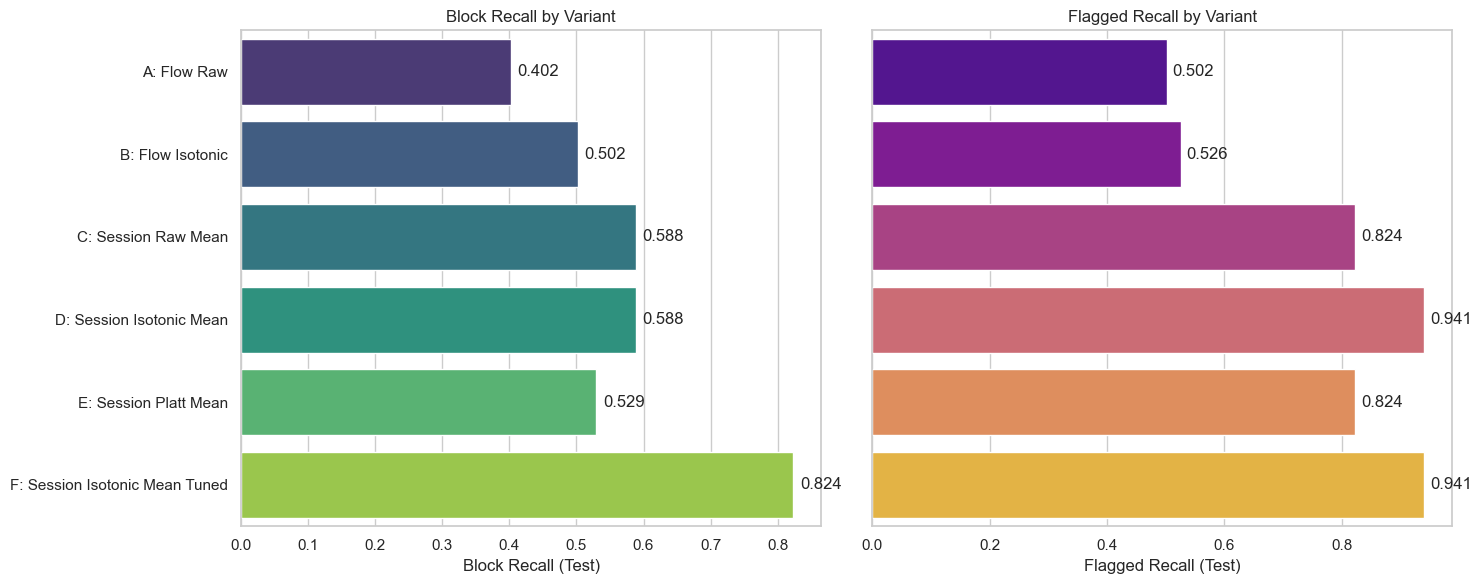

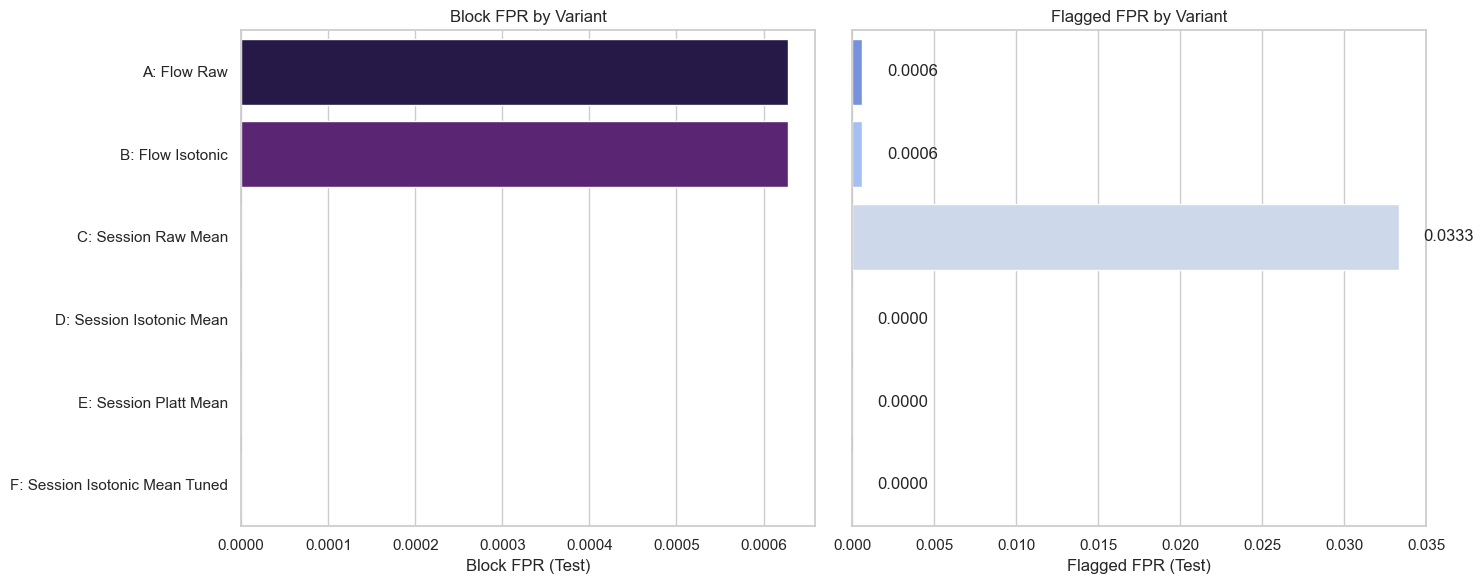

In [18]:
plot_order = df_ablation["Variant"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=df_ablation,
    x="block_recall",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="viridis",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Block Recall by Variant")
axes[0].set_xlabel("Block Recall (Test)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.3f}", (w + 0.01, p.get_y() + p.get_height() / 2), va="center")

sns.barplot(
    data=df_ablation,
    x="flagged_recall",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="plasma",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Flagged Recall by Variant")
axes[1].set_xlabel("Flagged Recall (Test)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.3f}", (w + 0.01, p.get_y() + p.get_height() / 2), va="center")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=df_ablation,
    x="block_fpr",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="magma",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Block FPR by Variant")
axes[0].set_xlabel("Block FPR (Test)")
axes[0].set_ylabel("")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.4f}", (w + 0.0015, p.get_y() + p.get_height() / 2), va="center")

sns.barplot(
    data=df_ablation,
    x="flagged_fpr",
    y="Variant",
    hue="Variant",
    dodge=False,
    order=plot_order,
    palette="coolwarm",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Flagged FPR by Variant")
axes[1].set_xlabel("Flagged FPR (Test)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.4f}", (w + 0.0015, p.get_y() + p.get_height() / 2), va="center")

plt.tight_layout()
plt.show()

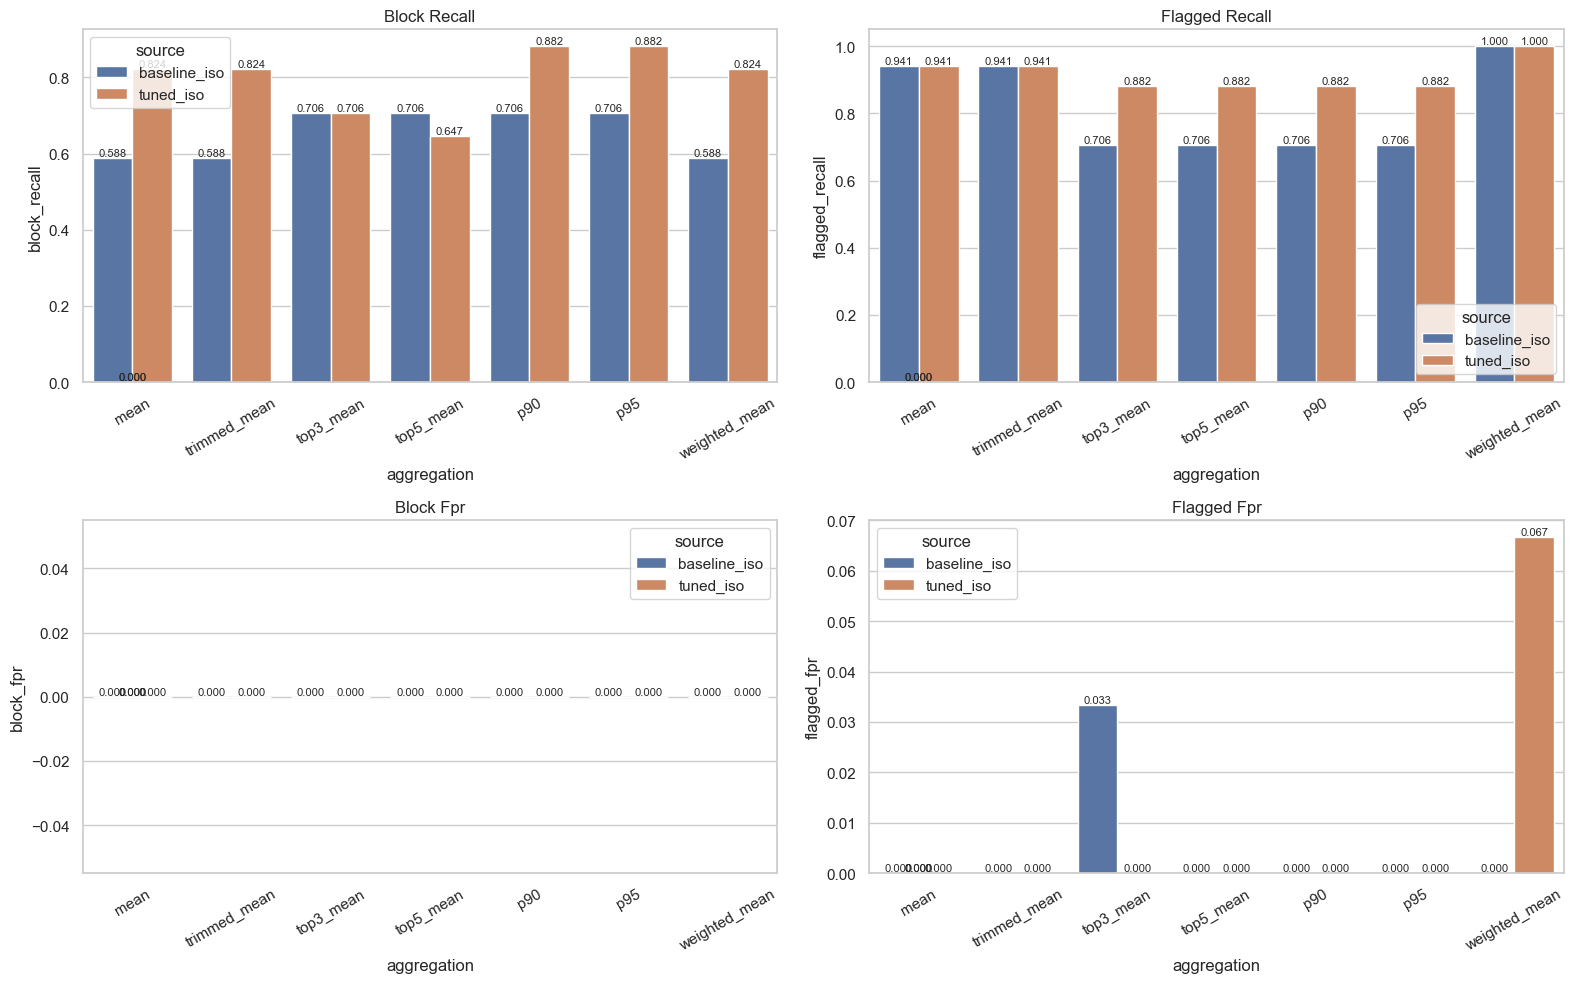

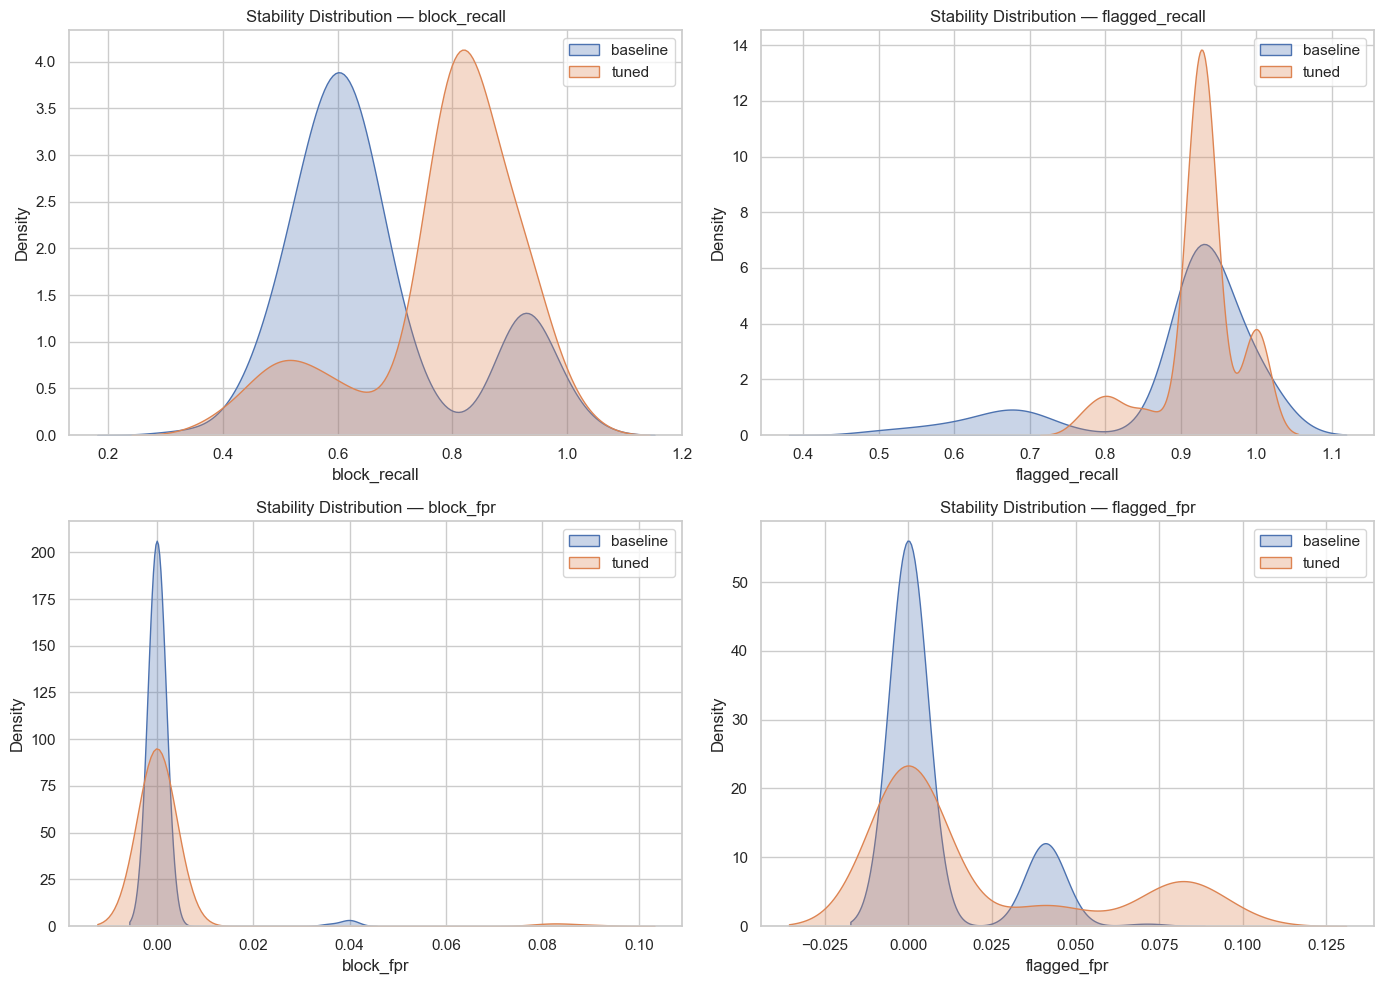

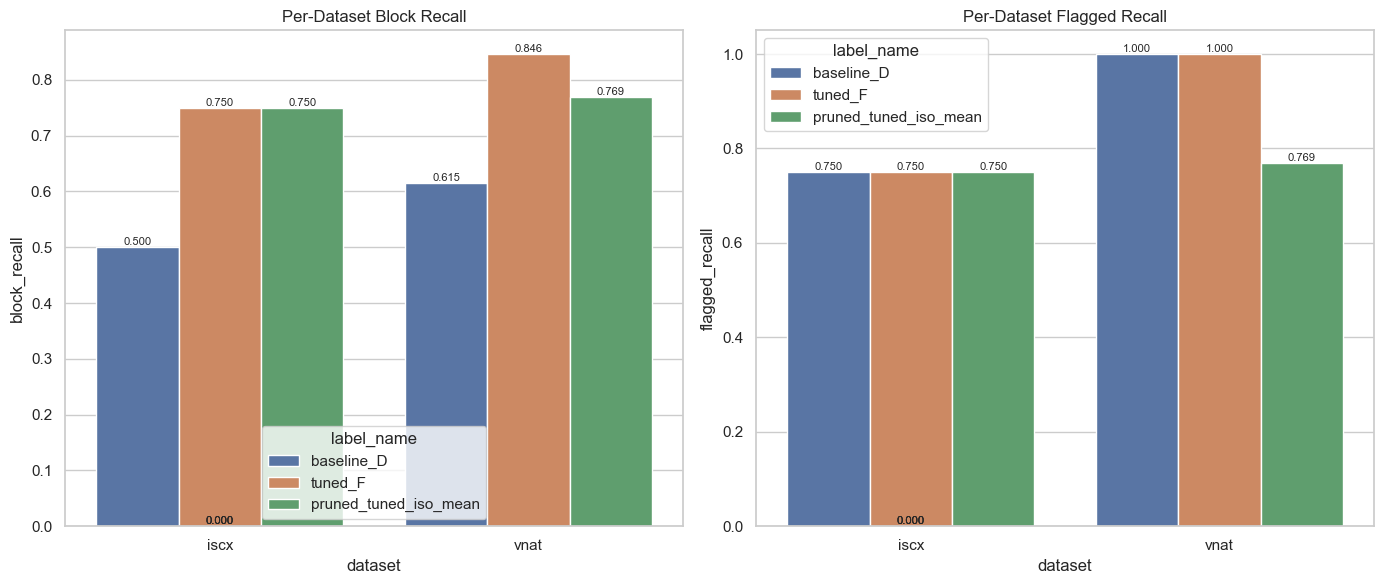

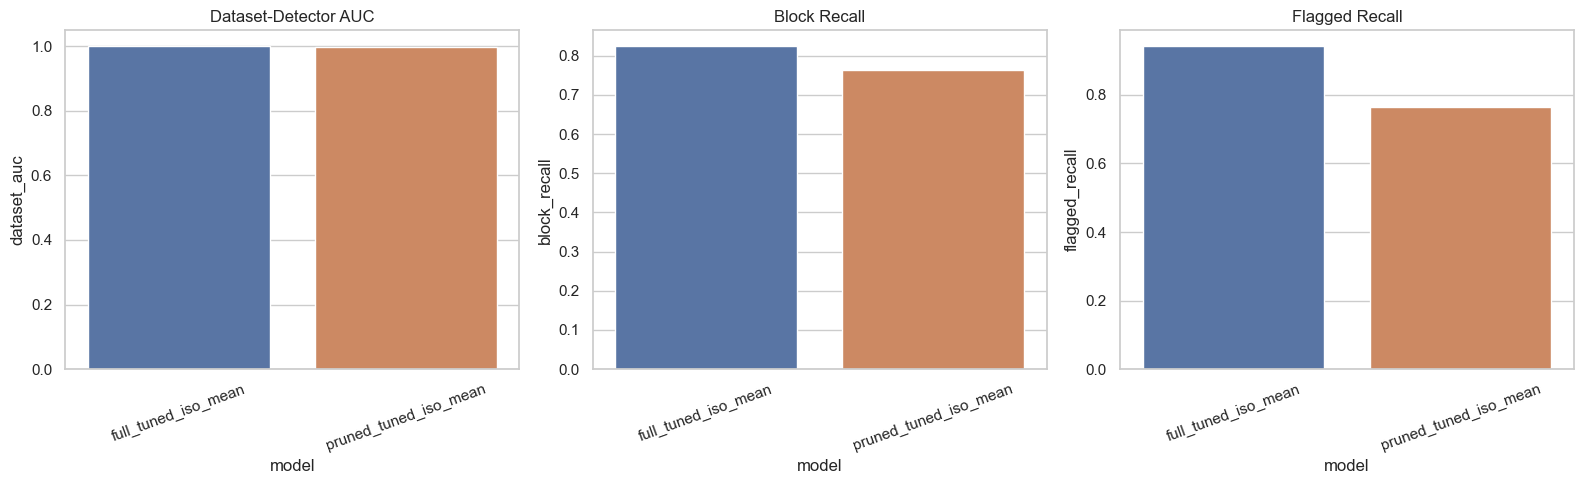

In [19]:
# Aggregation comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_metrics = ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr"]

for ax, metric in zip(axes.ravel(), plot_metrics):
    sns.barplot(
        data=df_agg,
        x="aggregation",
        y=metric,
        hue="source",
        ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Stability distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.ravel(), ["block_recall", "flagged_recall", "block_fpr", "flagged_fpr"]):
    sns.kdeplot(df_stability_base[metric], label="baseline", fill=True, alpha=0.3, ax=ax)
    sns.kdeplot(df_stability_tuned[metric], label="tuned", fill=True, alpha=0.3, ax=ax)
    ax.set_title(f"Stability Distribution — {metric}")
    ax.legend()

plt.tight_layout()
plt.show()

# Per-dataset comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_per_dataset,
    x="dataset",
    y="block_recall",
    hue="label_name",
    ax=axes[0],
)
axes[0].set_title("Per-Dataset Block Recall")
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

sns.barplot(
    data=df_per_dataset,
    x="dataset",
    y="flagged_recall",
    hue="label_name",
    ax=axes[1],
)
axes[1].set_title("Per-Dataset Flagged Recall")
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Feature pruning comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=compare_pruning, x="model", y="dataset_auc", hue="model", dodge=False, legend=False, ax=axes[0])
axes[0].set_title("Dataset-Detector AUC")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=compare_pruning, x="model", y="block_recall", hue="model", dodge=False, legend=False, ax=axes[1])
axes[1].set_title("Block Recall")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=compare_pruning, x="model", y="flagged_recall", hue="model", dodge=False, legend=False, ax=axes[2])
axes[2].set_title("Flagged Recall")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Save the main result tables so they can be reused in slides or the thesis writeup.

In [20]:
(df_ablation).to_csv(output_dir / "ablation_corrected.csv", index=False)
(df_agg).to_csv(output_dir / "aggregation_comparison.csv", index=False)
(df_stability_base).to_csv(output_dir / "stability_baseline.csv", index=False)
(df_stability_tuned).to_csv(output_dir / "stability_tuned.csv", index=False)
(df_per_dataset).to_csv(output_dir / "per_dataset_comparison.csv", index=False)
(compare_pruning).to_csv(output_dir / "feature_pruning_comparison.csv", index=False)

summary_manifest = {
    "features_yaml": str(features_yaml),
    "feature_config_hash": feature_config_hash_text(features_yaml),
    "baseline_predictions": str(baseline_preds_path),
    "tuned_predictions": str(tuned_preds_path),
    "output_dir": str(output_dir),
    "best_params": best_params,
    "pruned_features": prune_feats,
    "n_features_full": len(feature_cols),
    "n_features_pruned": len(feature_cols_pruned),
}

(output_dir / "notebook_manifest.json").write_text(json.dumps(summary_manifest, indent=2), encoding="utf-8")
print("Saved outputs under:", output_dir)

Saved outputs under: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned


The final section prints a conservative interpretation block.
It should only claim what the paired comparisons and stability analysis actually support.

In [21]:
print("\n" + "=" * 80)
print("FINAL THESIS-SAFE INTERPRETATION")
print("=" * 80)

A = df_ablation[df_ablation["Variant"] == "A: Flow Raw"].iloc[0]
B = df_ablation[df_ablation["Variant"] == "B: Flow Isotonic"].iloc[0]
C = df_ablation[df_ablation["Variant"] == "C: Session Raw Mean"].iloc[0]
D = df_ablation[df_ablation["Variant"] == "D: Session Isotonic Mean"].iloc[0]
E = df_ablation[df_ablation["Variant"] == "E: Session Platt Mean"].iloc[0]
F = df_ablation[df_ablation["Variant"] == "F: Session Isotonic Mean Tuned"].iloc[0]

best_base_agg = df_agg[df_agg["source"] == "baseline_iso"].sort_values("balanced_rank_score", ascending=False).iloc[0]
best_tuned_agg = df_agg[df_agg["source"] == "tuned_iso"].sort_values("balanced_rank_score", ascending=False).iloc[0]

zero_block_freq_base = float((df_stability_base["block_fpr"] == 0.0).mean()) if len(df_stability_base) else np.nan
zero_block_freq_tuned = float((df_stability_tuned["block_fpr"] == 0.0).mean()) if len(df_stability_tuned) else np.nan

print(f"""
1. Does session aggregation help?
   Compare A/B (flow-level) against C/D/E (session-level).
   Flow raw block recall: {A['block_recall']:.4f}
   Session isotonic mean block recall: {D['block_recall']:.4f}
   Flow raw flagged recall: {A['flagged_recall']:.4f}
   Session isotonic mean flagged recall: {D['flagged_recall']:.4f}
   Interpretation:
   Session aggregation should be considered beneficial only because the session-level paired comparisons improve the firewall metrics materially.

2. Does isotonic calibration help?
   Flow-level A -> B:
     block_recall delta = {B['block_recall'] - A['block_recall']:+.4f}
     flagged_recall delta = {B['flagged_recall'] - A['flagged_recall']:+.4f}
   Session-level C -> D:
     block_recall delta = {D['block_recall'] - C['block_recall']:+.4f}
     flagged_recall delta = {D['flagged_recall'] - C['flagged_recall']:+.4f}
     flagged_fpr delta = {D['flagged_fpr'] - C['flagged_fpr']:+.4f}
   Interpretation:
   Isotonic should only be claimed as helpful where the paired comparison actually improves session firewall behavior.

3. Does tuning help?
   D -> F:
     block_recall delta = {F['block_recall'] - D['block_recall']:+.4f}
     flagged_recall delta = {F['flagged_recall'] - D['flagged_recall']:+.4f}
     block_fpr delta = {F['block_fpr'] - D['block_fpr']:+.4f}
     flagged_fpr delta = {F['flagged_fpr'] - D['flagged_fpr']:+.4f}
   Interpretation:
   Tuning should only be called an improvement if the gain in block recall is not offset by an unacceptable increase in false positives.

4. Which aggregation rule is best?
   Best baseline isotonic aggregator (deployment-oriented): {best_base_agg['aggregation']}
     block_recall={best_base_agg['block_recall']:.4f}, flagged_recall={best_base_agg['flagged_recall']:.4f}, block_fpr={best_base_agg['block_fpr']:.4f}, flagged_fpr={best_base_agg['flagged_fpr']:.4f}
   Best tuned isotonic aggregator (deployment-oriented): {best_tuned_agg['aggregation']}
     block_recall={best_tuned_agg['block_recall']:.4f}, flagged_recall={best_tuned_agg['flagged_recall']:.4f}, block_fpr={best_tuned_agg['block_fpr']:.4f}, flagged_fpr={best_tuned_agg['flagged_fpr']:.4f}

5. Does domain-aware tuning improve robustness?
   Check the per-dataset comparison table.
   That table is the right place to judge whether the tuned configuration improves both VNAT and ISCX rather than only the combined metric.

6. Does feature pruning reduce domain shift without destroying firewall performance?
   Dataset-detector AUC:
     full   = {dataset_auc_full:.4f}
     pruned = {dataset_auc_pruned:.4f}
   Use this together with the full vs pruned firewall metrics to decide whether pruning helped robustness enough to justify any loss in performance.

7. Stability:
   Zero-block-FPR frequency under repeated resampling:
     baseline = {zero_block_freq_base:.4f}
     tuned    = {zero_block_freq_tuned:.4f}
   This is more informative than a single headline result because it tests whether the zero-blocking-FP behavior is stable after repeated threshold tuning.

8. Final recommended deployment configuration:
   Choose the configuration that satisfies:
   - block_fpr == 0 as often as possible
   - lowest flagged_fpr
   - strongest block_recall
   - strong flagged_recall
   - acceptable per-dataset behavior on both VNAT and ISCX
   Do not select the final model purely by AUC.
""")


FINAL THESIS-SAFE INTERPRETATION

1. Does session aggregation help?
   Compare A/B (flow-level) against C/D/E (session-level).
   Flow raw block recall: 0.4024
   Session isotonic mean block recall: 0.5882
   Flow raw flagged recall: 0.5020
   Session isotonic mean flagged recall: 0.9412
   Interpretation:
   Session aggregation should be considered beneficial only because the session-level paired comparisons improve the firewall metrics materially.

2. Does isotonic calibration help?
   Flow-level A -> B:
     block_recall delta = +0.0996
     flagged_recall delta = +0.0239
   Session-level C -> D:
     block_recall delta = +0.0000
     flagged_recall delta = +0.1176
     flagged_fpr delta = -0.0333
   Interpretation:
   Isotonic should only be claimed as helpful where the paired comparison actually improves session firewall behavior.

3. Does tuning help?
   D -> F:
     block_recall delta = +0.2353
     flagged_recall delta = +0.0000
     block_fpr delta = +0.0000
     flagged_fpr 